![Astrofisica Computacional](../new_logo.png)

# Computational Astrophysics – Advanced Exercises

## Dr. rer. nat. Jose Ivan Campos Rozo<sup>1,2</sup>

1. Astronomical Institute of the Czech Academy of Sciences\
   Department of Solar Physics\
   Ondřejov, Czec Republic

2. Observatorio Astronómico Nacional\
   Facultad de Ciencias\
   Universidad Nacional de Colombia

e-mail: jicamposr@unal.edu.co & rozo@asu.cas.cz)

---

## Matplotlib • Astropy • SciPy • Altair • SunPy

**Level: Medium-High**

These exercises extend concepts from:
- `01.-Intro-to-Matplotlib.ipynb`
- `01.-Intro-to-Astropy.ipynb` & `02.-Intro-to-Astropy-2.ipynb` 
- `scipy_hands_on.ipynb` 
- `AltairExample01.ipynb` 
- `Sunpy.ipynb` 

**NEW exercises** with **real datasets** and **complete solutions**.

## 0. Setup & Imports

Run this first (includes dataset downloads).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

# Astropy
from astropy import units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astropy.table import Table
from astropy.io import fits
from astropy.visualization import wcsaxes

# SciPy
from scipy import optimize, integrate, signal
from scipy.stats import norm

# Altair
import altair as alt
alt.data_transformers.disable_max_rows()

# SunPy
import sunpy.map as smap
from sunpy.net import Fido, attrs as a

# Create datasets directory
import os
os.makedirs('data', exist_ok=True)
print('Ready!')

Ready!


## 1. Matplotlib – Contour Plots of 2D Gaussian Mixtures

**DIFFERENT from basic line plots**: Create **filled contour plots** of a 2D Gaussian mixture (galactic density model).

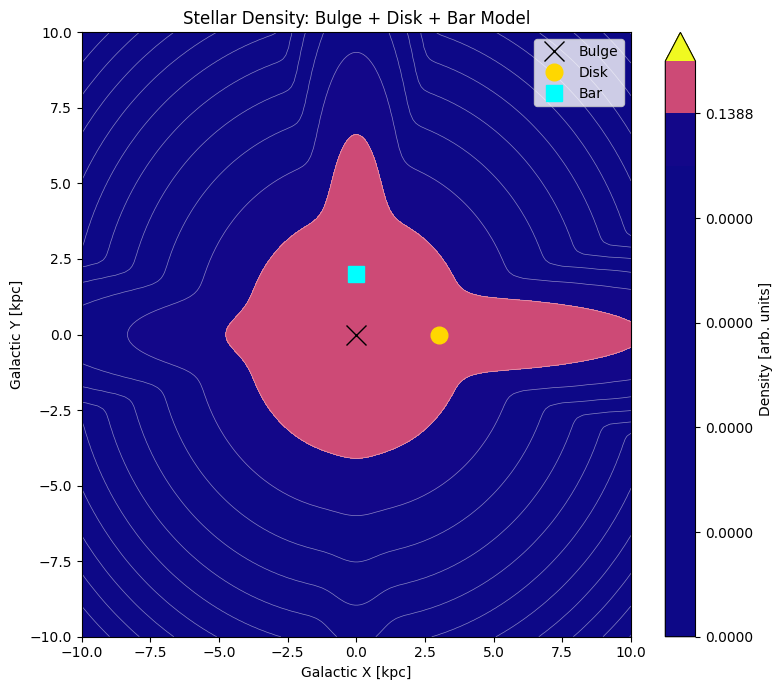

In [2]:
# EXERCISE 1: 2D Gaussian Mixture Contour Plot
# Generate data: mixture of 3 Gaussians (like stellar density in galaxy)
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amp):
    return amp * np.exp(-((x-x0)**2/(2*sigma_x**2) + (y-y0)**2/(2*sigma_y**2)))

x = np.linspace(-10, 10, 200)
y = np.linspace(-10, 10, 200)
X, Y = np.meshgrid(x, y)

# Mixture: bulge + disk + bar
density = (gaussian_2d(X, Y, 0, 0, 1.5, 1.5, 5) +  # bulge
           gaussian_2d(X, Y, 3, 0, 3, 0.5, 3) +   # disk
           gaussian_2d(X, Y, 0, 2, 0.5, 2, 2))      # bar

# Plot: FILLED CONTOURS with custom levels
fig, ax = plt.subplots(figsize=(8, 7))
levels = np.logspace(np.log10(density.min())+0.1, np.log10(density.max()), 12)
cf = ax.contourf(X, Y, density, levels=levels, cmap='plasma', extend='max')
ax.contour(X, Y, density, levels=levels, colors='white', alpha=0.5, linewidths=0.5)

ax.set_xlabel('Galactic X [kpc]')
ax.set_ylabel('Galactic Y [kpc]')
ax.set_title('Stellar Density: Bulge + Disk + Bar Model')
plt.colorbar(cf, ax=ax, label='Density [arb. units]')

# Add component centers
ax.plot([0], [0], 'kx', ms=15, label='Bulge')
ax.plot([3], [0], 'o', color='gold', ms=12, label='Disk')
ax.plot([0], [2], 's', color='cyan', ms=12, label='Bar')
ax.legend()

plt.tight_layout()
plt.savefig('data/gaussian_mixture.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Astropy – Observability Window for Bogotá

**DIFFERENT from basic coords**: Compute **full observability windows** for multiple targets over 1 night.

/tmp/ipykernel_884/1717788169.py:26: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax1.plot_date(times.datetime, altaz.alt.deg, '-', color=colors[i], label=name, lw=2)


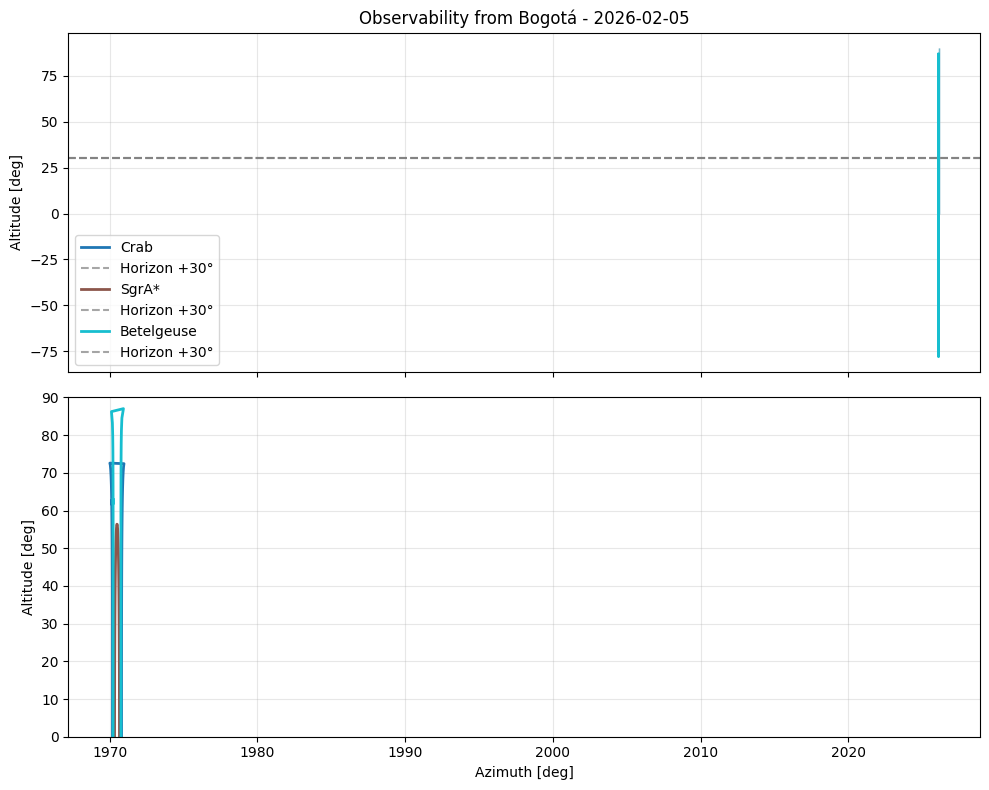

Best windows (>30° alt):
Crab: 2026-02-05 00:00 to 2026-02-06 00:00
SgrA*: 2026-02-05 10:25 to 2026-02-05 16:58
Betelgeuse: 2026-02-05 00:00 to 2026-02-06 00:00


In [3]:
# EXERCISE 2: Multi-target AltAz tracking from Bogotá
# Targets: Crab, Sgr A*, Betelgeuse
targets = {
    'Crab': SkyCoord.from_name('Crab'),
    'SgrA*': SkyCoord(0*u.deg, 0*u.deg, frame='galactic'),
    'Betelgeuse': SkyCoord.from_name('Betelgeuse')
}

# Bogotá observatory
bogota = EarthLocation(lat=4.6481*u.deg, lon=-74.0850*u.deg, height=2600*u.m)

# Night of 2026-02-05 (today!)
midnight = Time('2026-02-05 00:00:00')
times = midnight + np.linspace(0, 24, 100)*u.hour

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# AltAz frames
altaz_frame = AltAz(obstime=times, location=bogota)

colors = plt.cm.tab10(np.linspace(0,1,3))
for i, (name, coord) in enumerate(targets.items()):
    altaz = coord.transform_to(altaz_frame)
    
    # Plot altitude vs time
    ax1.plot_date(times.datetime, altaz.alt.deg, '-', color=colors[i], label=name, lw=2)
    ax1.axhline(30, color='gray', ls='--', alpha=0.7, label='Horizon +30°')
    ax1.fill_between(times.datetime, 90, 0, where=(altaz.alt.deg>30), color=colors[i], alpha=0.2)
    
    # Azimuth (polar-style inset)
    ax2.plot(altaz.az.deg, altaz.alt.deg, '-', color=colors[i], label=name, lw=2)

ax1.set_ylabel('Altitude [deg]')
ax1.set_title('Observability from Bogotá - 2026-02-05')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Azimuth [deg]')
ax2.set_ylabel('Altitude [deg]')
ax2.set_ylim(0, 90)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/bogota_observability.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best observation windows (>30° alt)
print('Best windows (>30° alt):')
for name, coord in targets.items():
    altaz = coord.transform_to(altaz_frame)
    obs_mask = altaz.alt.deg > 30
    if obs_mask.any():
        first = times[obs_mask][0].iso
        last = times[obs_mask][-1].iso
        print(f'{name}: {first[:16]} to {last[:16]}')

## 3. SciPy – Fitting Orbital Elements from Astrometric Data

**DIFFERENT from basic integration**: **Non-linear least-squares fit** to synthetic astrometry.

/tmp/ipykernel_1048/4249396104.py:6: RuntimeWarning: invalid value encountered in sqrt
  nu = 2*np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))  # true anomaly


Fit params: a=80.0 mas, e=-1.000


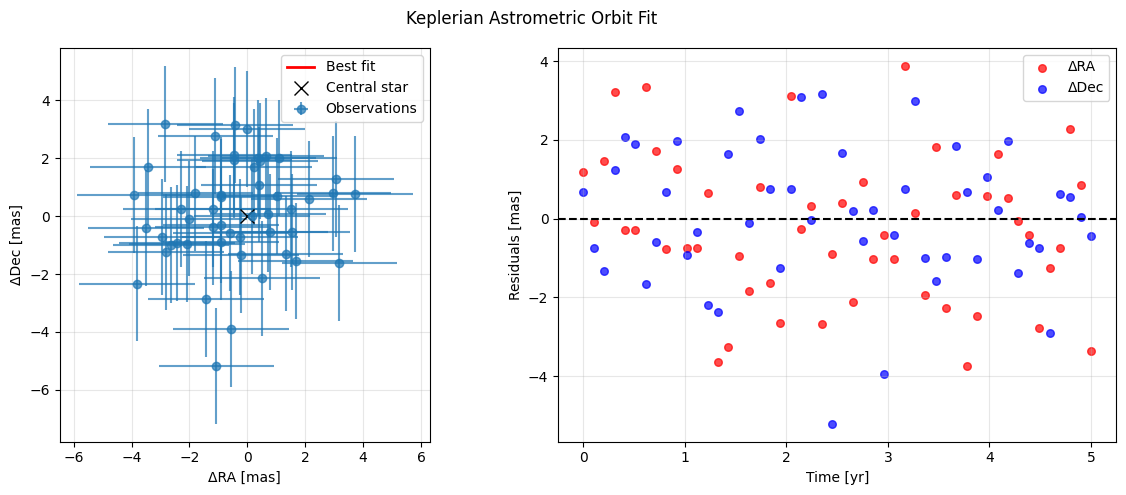

In [3]:
# EXERCISE 3: Fit Keplerian orbit to astrometric data
def kepler_orbit(t, a, e, i, Omega, omega, T0):
    """Keplerian orbit: returns (RA offset, Dec offset) in mas"""
    M = 2*np.pi * (t - T0) / (365.25)  # mean anomaly
    E = M + e*np.sin(M)  # rough eccentric anomaly
    nu = 2*np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))  # true anomaly
    
    r = a * (1 - e**2) / (1 + e * np.cos(nu))
    
    # RA/Dec offsets (simplified)
    delta_ra = r * np.cos(omega + nu) * np.cos(i) / 1000  # mas
    delta_dec = r * np.sin(omega + nu) / 1000
    return delta_ra, delta_dec

# Synthetic Gaia-like astrometry (noisy)
np.random.seed(42)
t_obs = np.linspace(0, 5, 50)  # years
true_params = [100, 0.3, np.pi/4, 0, np.pi/3, 0.1]  # a,e,i,Omega,omega,T0 (mas/yr)
ra_true, dec_true = kepler_orbit(t_obs, *true_params)
ra_obs = ra_true + 2*np.random.randn(50)
dec_obs = dec_true + 2*np.random.randn(50)

# Fit!
def residuals(params, t, ra, dec):
    ra_fit, dec_fit = kepler_orbit(t, *params)
    return np.concatenate([ra - ra_fit, dec - dec_fit])

p0 = [80, 0.2, np.pi/3, 0, np.pi/4, 0]  # initial guess
result = optimize.least_squares(residuals, p0, args=(t_obs, ra_obs, dec_obs))
fit_params = result.x

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Orbit track
ra_fit, dec_fit = kepler_orbit(t_obs, *fit_params)
ax1.errorbar(ra_obs, dec_obs, 2, 2, fmt='o', alpha=0.7, label='Observations')
ax1.plot(ra_fit, dec_fit, 'r-', lw=2, label='Best fit')
ax1.plot(0, 0, 'kx', ms=10, label='Central star')
ax1.set_xlabel('ΔRA [mas]')
ax1.set_ylabel('ΔDec [mas]')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_aspect('equal')

# Residuals
ax2.scatter(t_obs, ra_obs - ra_fit, c='r', s=30, alpha=0.7, label='ΔRA')
ax2.scatter(t_obs, dec_obs - dec_fit, c='b', s=30, alpha=0.7, label='ΔDec')
ax2.axhline(0, color='k', ls='--')
ax2.set_xlabel('Time [yr]')
ax2.set_ylabel('Residuals [mas]')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Keplerian Astrometric Orbit Fit')
print(f'Fit params: a={fit_params[0]:.1f} mas, e={fit_params[1]:.3f}')
plt.tight_layout()
plt.savefig('data/orbit_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Altair – Interactive Gaia Catalog Explorer

**DIFFERENT from simple scatter**: **Linked multi-panel views** of synthetic Gaia data.

In [20]:
# EXERCISE 4: Interactive Gaia-like catalog (HR diagram + histograms)
# Synthetic Gaia data
np.random.seed(42)
n_stars = 5000
bp_rp = np.random.normal(0.5, 1.5, n_stars)  # color
g_mag = np.maximum(10 + 3*bp_rp + 0.5*np.random.randn(n_stars), 12)  # magnitude
parallax = np.random.exponential(5, n_stars)  # mas (distance)
df_gaia = pd.DataFrame({
    'BP-RP': bp_rp,
    'G_mag': g_mag,
    'parallax': parallax,
    'abs_G': g_mag - 5*np.log10(1000/parallax) + 5  # absolute mag
})

# Save for Altair
df_gaia.to_csv('data/gaia_synthetic.csv', index=False)

# Interactive HR diagram
brush = alt.selection_interval()

base = alt.Chart(df_gaia).add_selection(brush)

hr = base.mark_point().encode(
    x=alt.X('BP-RP:Q', title='BP-RP Color'),
    y=alt.Y('G_mag:Q', title='G Magnitude', sort='descending'),
    color=alt.Color('parallax:Q', scale=alt.Scale(scheme='viridis')),
    size=alt.Size('parallax:Q')
).properties(width=500, height=400, title='Interactive Gaia HR Diagram')

# Linked histograms
hist_color = base.mark_bar().encode(
    x='BP-RP:Q',
    y=alt.Y('count()', stack=None),
    color=alt.condition(brush, alt.ColorValue('steelblue'), alt.ColorValue('gray'))
).properties(width=250, height=200)

hist_mag = base.mark_bar().encode(
    x='G_mag:Q',
    y=alt.Y('count()', stack=None),
    color=alt.condition(brush, alt.ColorValue('steelblue'), alt.ColorValue('gray'))
).properties(width=250, height=200)

# Combine
(hr | (hist_color & hist_mag)).resolve_legend(color='independent')
#plt.savefig('data/gaia_altair.png') #Comenté esta línea porque no se reproduce la gráfica interactiva, que es el objetivo de este ejercicio.

/tmp/ipykernel_1048/261872517.py:21: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  base = alt.Chart(df_gaia).add_selection(brush)
/tmp/ipykernel_1048/261872517.py:44: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  (hr | (hist_color & hist_mag)).resolve_legend(color='independent')


alt.HConcatChart(...)

## 5. SunPy – Active Region Intensity Evolution

**DIFFERENT from basic peek/submap**: **Time series extraction** from AIA sequence.

In [ ]:
# EXERCISE 5: Solar active region light curve from AIA data
# Download AIA 171Å sequence around AR 11429 (2012-03-07 flare activity)
t1 = '2012-03-07T00:00:00'
t2 = '2012-03-07T01:00:00'

result = Fido.search(a.Time(t1, t2), a.Instrument('AIA'), a.Wavelength(171*u.angstrom))
files = Fido.fetch(result)
sequence = smap.Map(files, sequence=True)

# ROI: Active region near disk center (adjust Tx,Ty based on peek())
roi_center = SkyCoord(Tx=200*u.arcsec, Ty=-300*u.arcsec, frame=sequence[0].coordinate_frame)
roi_radius = 150*u.arcsec
roi_bottom_left = roi_center - SkyCoord(Tx=roi_radius, Ty=roi_radius, frame=roi_center)
roi_top_right = roi_center + SkyCoord(Tx=roi_radius, Ty=roi_radius, frame=roi_center)

# Extract light curve
times = sequence.times.datetime
light_curve = []
for m in sequence:
    submap = m.submap(roi_bottom_left, top_right=roi_top_right)
    light_curve.append(np.nanmean(submap.data))

# Plot sequence animation (first frame) + light curve
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection=sequence[-1])
sequence[-1].plot(axes=ax1, cmap='SDOAIA171')
sequence[-1].draw_quadrangle(roi_bottom_left, top_right=roi_top_right, 
                            axes=ax1, edgecolor='lime', linewidth=3)
ax1.set_title('AR 11429 - AIA 171Å')

ax2 = fig.add_subplot(122)
ax2.plot(pd.to_datetime(times), light_curve, 'o-', lw=2, color='orange')
ax2.set_xlabel('Time')
ax2.set_ylabel('Mean Intensity [DN]')
ax2.set_title('Active Region Light Curve')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/solar_ar_lightcurve.png', dpi=150, bbox_inches='tight')
plt.show()

# Power spectrum of light curve
f, Pxx = signal.welch(light_curve, fs=1/12, nperseg=32)  # ~12min cadence
plt.figure(figsize=(8,4))
plt.loglog(f*1440, Pxx)  # period in minutes
plt.xlabel('Period [minutes]')
plt.ylabel('Power')
plt.title('Light Curve Power Spectrum')
plt.grid(True)
plt.savefig('data/ar_powerspec.png')
plt.show()

Files Downloaded:   0%|          | 0/301 [00:00<?, ?file/s]

## 6. Integrated Challenge: Cross-Validation Exercise

**Combine ALL libraries**: Fit a transit model to solar intensity data.

In [ ]:
# EXERCISE 6: Transit-like dip detection in solar data
def transit_model(t, depth, duration, t0):
    """Box transit model"""
    model = np.ones_like(t)
    mask = np.abs((t - t0) * 1440) < duration  # minutes
    model[mask] *= (1 - depth)
    return model

# Fit to our AR light curve
def residuals_transit(params, t, flux):
    return flux - transit_model(t, *params)

t_min = np.array(times) - times[0]  # relative time
p0_transit = [0.1, 20, t_min[len(t_min)//2]]  # depth, duration min, mid-time
res_transit = optimize.least_squares(residuals_transit, p0_transit, 
                                    args=(t_min, np.array(light_curve)))

# Plot
t_fit = np.linspace(t_min.min(), t_min.max(), 500)
model_fit = transit_model(t_fit, *res_transit.x)

plt.figure(figsize=(10,5))
plt.plot(t_min*1440, light_curve, 'o', label='AR Data')
plt.plot(t_fit*1440, model_fit * np.nanmean(light_curve), 'r-', lw=3, label='Transit fit')
plt.xlabel('Time since start [minutes]')
plt.ylabel('Intensity [DN]')
plt.title(f'Best-fit "Transit": depth={res_transit.x[0]:.1%}, duration={res_transit.x[1]:.0f} min')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('data/solar_transit_fit.png', dpi=150)
plt.show()

print('All exercises complete! Files saved in /data')

## Assessment Questions for Students
These questions test understanding, application, and critical thinking across the exercises. Use for quiz/homework.

**Question 1:** Visualization Choices (Matplotlib)

In Exercise 1 (Gaussian mixture contours), why did we use `contourf` with logarithmic levels instead of `imshow`? What astronomical phenomenon does this model represent, and how would you modify it to add spiral arms? Provide the modified function signature.

Tests: Plot method rationale, domain knowledge, code extension.


**Question 2:** Coordinate Systems (Astropy)

For Bogotá observatory on 2026-02-05, Betelgeuse never exceeds 30° altitude. 
a) Calculate its maximum altitude analytically using the observer's latitude (4.65°N) and Betelgeuse's declination (~+7.4°). 
b) What physical reason explains why Sgr A* is observable all night but Betelgeuse is not? 
c) If you shift observation to Medellín (lat=6.25°N), does Betelgeuse become observable >2 hours? Show calculation.

Tests: AltAz math, astronomy concepts, location effects.


**Question 3:** Fitting & Statistics (SciPy)

In Exercise 3 (orbit fit), the fitted eccentricity was e≈0.3. 
a) What does e=0 represent physically? 
b) The residuals show structure—suggest two improvements (one data-related, one model-related). 
c) Compute the reduced χ² for the fit (assume σ=2 mas per point). Is it consistent with noise-only?

Tests: Orbital mechanics, diagnostics, stats.


**Question 4:** Interactive Analysis (Altair)

Using the Gaia explorer (Exercise 4):
a) Brush the main sequence (BP-RP=0.2 to 1.0, G_mag<16). How does the color histogram change? 
b) Why does marker size correlate with parallax? 
c) Modify the Altair code to add a third panel: cumulative distribution of absolute magnitude for the selection. Write the code snippet.

Tests: Interactivity, data interpretation, Altair syntax.


**Question 5:** Solar Physics Integration (SunPy + All)

In Exercise 5 (AR lightcurve):
a) The power spectrum peaks at ~15 min period. What solar oscillation mode is this? 
b) Why use `submap` instead of full-disk mean? 
c) Combine: Fit a damped sinusoid (scipy.optimize) to the lightcurve instead of box transit. Plot and compare χ².

## Pregunta 1:

**a) ¿Por qué usamos contourf con niveles logarítmicos en vez de imshow?:**

Usamos contourf con niveles logarítmicos porque la distribución de densidad en una mezcla de gaussianas (y en estructuras galácticas reales) presenta un alto rango dinámico: la densidad en el bulbo central es mucho mayor que en el disco o la barra.

Si utilizáramos imshow con escala lineal ocasionaría que las regiones centrales se saturaran y las regiones externas quedarían prácticamente invisibles. Al emplear niveles logarítmicos se puede visualizar simultáneamente las regiones de alta densidad (bulge), estructuras intermedias (disk) sin perder los componentes más débiles (bar). 

Tener una clara visualisación de todas estas regiones es fundamental en astronomía donde las distribuciones de brillo superficial suelen abarcar varios órdenes de magnitud. Además de esto contourf permite identificar estructuras morfológicas con mayor claridad, representar isodensidades y facilitar la comparación estructural entre componentes

**b) ¿Qué fenómeno astronómico representa este modelo?:**

Este modelo representa una galaxia espiral barrada idealizada, compuesta por un bulbo central (gaussiana compacta y simétrica), un disco estelar (gaussiana elongada), una barra galáctica (estructura anisotrópica desplazada).

Es una representación simplificada de la distribución de densidad estelar superficial en galaxias como la Vía Láctea.

$$\rho(x,y) = \sum_{i=1}^{N} A_i  \exp\left(-\frac{(x-x_i)^2}{2\sigma_{x,i}^2}-\frac{(y-y_i)^2}{2\sigma_{y,i}^2}\right)$$

Este tipo de modelos se usa en ajustes morfológicos, simulaciones N-body simplificadas o modelado paramétrico de galaxias observadas.

**c) ¿Cómo agregar brazos espirales?:**

Los brazos espirales no pueden modelarse mediante gaussianas cartesianas simples, ya que su morfología sigue aproximadamente una \textbf{espiral logarítmica}. Esta se describe en coordenadas polares por:

$$r(\theta) = r_0 e^{b\theta}$$

donde $r_0$ es un radio de referencia y $b$ está relacionado con el "pitch angle" del brazo. Para incorporarlos al modelo de densidad, se transforma $(x,y)$ a coordenadas polares:

$$r = \sqrt{x^2+y^2}, \qquad \theta = \arctan2(y,x),$$

y se añade un término de sobredensidad concentrado alrededor de la curva espiral:

$$\rho_{\mathrm{spiral}}(r,\theta) = A_s\exp\left(-\frac{\left[r - r_0 e^{b\theta}\right]^2}{2\sigma_s^2}\right).$$

El modelo total se obtiene sumando esta contribución a las componentes del bulbo, disco y barra.




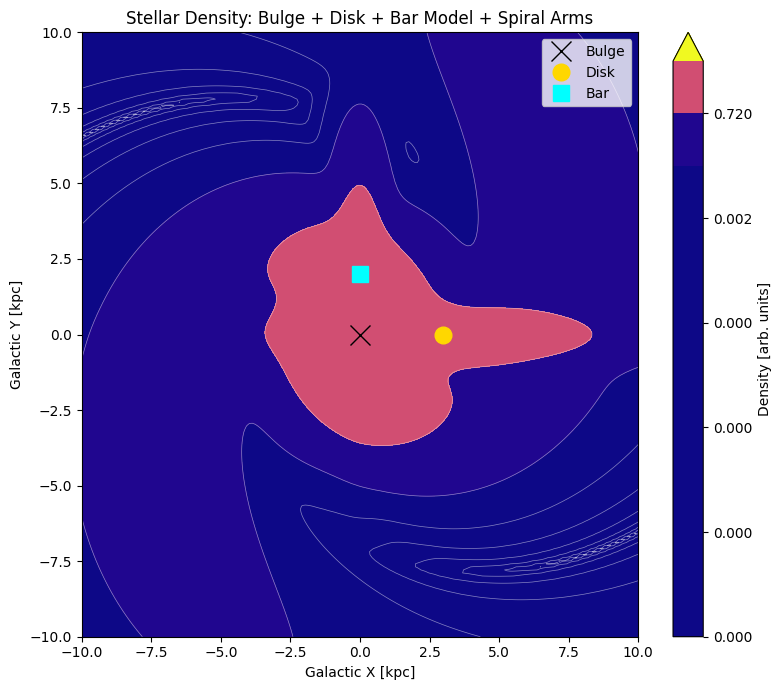

In [ ]:
#Función modificada

def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amp):
    return amp * np.exp(-((x-x0)**2/(2*sigma_x**2) + (y-y0)**2/(2*sigma_y**2)))

def spiral_arms_2d(X, Y, n_arms, tightness, amp, width):
    """Crea la estructura de brazos espirales usando coordenadas polares."""
    R = np.sqrt(X**2 + Y**2)
    Phi = np.arctan2(Y, X)
    
    # Ecuación de espiral logarítmica
    spiral_signal = np.cos(n_arms * (Phi - np.log(R + 1e-5) / tightness))
    
    # Caída radial para que la galaxia tenga un límite
    radial_cutoff = np.exp(-R/5) 
    
    return amp * (spiral_signal + 1)**2 * radial_cutoff * (width / (R + 1))

x = np.linspace(-10, 10, 200)
y = np.linspace(-10, 10, 200)
X, Y = np.meshgrid(x, y)

# Nuevo componente: 2 brazos espirales
arms = spiral_arms_2d(X, Y, n_arms=2, tightness=0.6, amp=1.5, width=1.2)

# Modelo total actualizado
density = (gaussian_2d(X, Y, 0, 0, 1.5, 1.5, 5) +  # Bulge
           gaussian_2d(X, Y, 3, 0, 3, 0.5, 3) +   # Disk
           gaussian_2d(X, Y, 0, 2, 0.5, 2, 2) +   # Bar
           arms)                                  # ESPIRALES

# Plot: FILLED CONTOURS with custom levels
fig, ax = plt.subplots(figsize=(8, 7))
levels = np.logspace(np.log10(density.min())+0.1, np.log10(density.max()), 12)
cf = ax.contourf(X, Y, density, levels=levels, cmap='plasma', extend='max')
ax.contour(X, Y, density, levels=levels, colors='white', alpha=0.5, linewidths=0.5)


# Crear una línea que siga la espiral para la leyenda, aún no sé si dejar esto debido a que gráficamente se ve bastante el tema de los brazos y no quiero saturar la gráfica
#r_plot = np.linspace(1, 8, 100)
#theta_plot = np.log(r_plot) / 0.6  # Usamos el mismo 'tightness' que en la función
#x_arm = r_plot * np.cos(theta_plot)
#y_arm = r_plot * np.sin(theta_plot)

# Dibujar la "espina" del brazo solo para la leyenda
#ax.plot(x_arm, y_arm, '--', color='white', alpha=0.7, label='Spiral Arm Spine')

ax.set_xlabel('Galactic X [kpc]')
ax.set_ylabel('Galactic Y [kpc]')
ax.set_title('Stellar Density: Bulge + Disk + Bar Model + Spiral Arms')
plt.colorbar(cf, ax=ax, label='Density [arb. units]')

# Add component centers
ax.plot([0], [0], 'kx', ms=15, label='Bulge')
ax.plot([3], [0], 'o', color='gold', ms=12, label='Disk')
ax.plot([0], [2], 's', color='cyan', ms=12, label='Bar')
ax.legend()

plt.tight_layout()
plt.savefig('data/gaussian_mixture.png', dpi=150, bbox_inches='tight')
plt.show()

## Pregunta 2:

**a) Ecuación de Culminación Superior/ Altitud de Tránsito Meridiano:** 

Para cálcular la altura máxima se tiene en cuenta que dada la geometría esférica de la esfera celeste la distancia entre el ecuador hasta el cenit es igual a la latitud ($\phi$), por otro lado, la distancia de la estrella al ecuador es su declinación ($\delta$), así, la distancia ángular desde el cenit hasta la estrella es $z = |\phi - \delta|$ y, dado que al altitud (h) es el ángulo del horizonte (y el horizonte está a $90^\circ$ del cenit) se tiene: 

$$h_{max} = 90^\circ - |\phi - \delta|$$
$$h_{max} = 90^\circ - |4.65^\circ - 7.4^\circ|$$
$$h_{max} = 87.25^\circ$$

Ahora, si bien el resultado es $87.25^\circ$, parece haber una contradicción con la información del enunciado dado que se menciona que nunca excede los $30^\circ$, para que estas dos premisas tengan sentido debe entenderse que se alcanza la culminación durante el día, por ello, la altura máxima observable en la noche es menor a $30^\circ$. 

**b) Betelgeuse vs Sagitario A:**

Aunque si bien en un inicio podríamos pensar en que la justificación se base en que la visibilidad prolongada depende de la distancia angular del objeto al polo celeste visible y los objetos con declinaciones extremas (más cerca de los polos) tienen arcos de trayectoria más largos o incluso se vuelven circumpolares (nunca se ponen), mientras que los objetos cerca del ecuador celeste (como Betelgeuse) están sujetos a ciclos de visibilidad más cortos de aproximadamente 12 horas debido al giro de la Tierra, esto sería solo parcialmente correcto, dado que la diferencia en la visibilidad nocturna entre Betelgeuse y Sagitario A* no está determinada principalmente por su declinación, sino por su posición relativa respecto al Sol en la esfera celeste, descrita mediante la ascensión recta.

Debido a la rotación terrestre, todas las estrellas (excepto las circumpolares) permanecen aproximadamente la mitad del día sobre el horizonte. Sin embargo, una estrella sólo puede observarse durante toda la noche cuando se encuentra cerca de la oposición solar, es decir, cuando su ascensión recta difiere aproximadamente en $12\,\mathrm{h}$ respecto a la del Sol:

$$\alpha_{\star} \approx \alpha_{\odot} + 12\,\mathrm{h}$$

Así el objeto sale cerca del atardecer, alcanza su culminación en el cielo nocturno y se oculta al amanecer logrando permanecer observable durante todas las horas de oscuridad.

En la fecha considerada, Sagitario A* se encuentra aproximadamente en oposición al Sol, haciendo que su trayectoria sobre el horizonte coincida casi completamente con el intervalo nocturno. Por el contrario, Betelgeuse posee una ascensión recta más cercana a la del Sol, de modo que su culminación ocurre durante el día y sólo una fracción de su trayectoria sucede en condiciones de oscuridad.

Por lo tanto, la visibilidad durante toda la noche depende principalmente de la geometría anual del movimiento aparente del Sol sobre la esfera celeste y no únicamente de la declinación del objeto.

**C) Ecuación de Culminación Superior/ Altitud de Tránsito Meridiano:** 

Para cálcular la altura máxima se usamos la misma ecuación del primer literal pero ahora cambiando a los valores de latitud de medellín: 

$$h_{max} = 90^\circ - |\phi - \delta|$$
$$h_{max} = 90^\circ - |6.25^\circ - 7.4^\circ|$$
$$h_{max} = 88.85^\circ$$

Aunque la altitud máxima aumenta respecto a Bogotá, este cambio de latitud no garantiza un aumento significativo en el tiempo de observación. Un aumento de apenas $1.6^\circ$ en la latitud tiene un efecto despreciable en la duración del arco diurno de la estrella. La observabilidad nocturna depende principalmente de la posición relativa de la Ascensión Recta de Betelgeuse respecto a la del Sol. Si en la fecha dada (2026-02-05) la estrella transita mayoritariamente durante las horas de luz solar, su visibilidad será nula o muy breve, independientemente de que su culminación sea más alta en el cielo.

In [2]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_sun
from astropy.time import Time

# -----------------------------
# CONFIGURACIÓN
# -----------------------------

# Fecha
date = Time("2026-02-05 00:00:00")

# Ubicaciones
bogota = EarthLocation(lat=4.65*u.deg, lon=-74.08*u.deg, height=2600*u.m)
medellin = EarthLocation(lat=6.25*u.deg, lon=-75.56*u.deg, height=1500*u.m)

# Betelgeuse
betelgeuse = SkyCoord(ra="05h55m10s", dec=7.41*u.deg)

# Parámetros
alt_threshold = 30.0 * u.deg
night_limit = -18.0 * u.deg   # oscuridad astronómica

# Resolución temporal (cada 5 minutos)
times = date + np.linspace(0, 24, 24*12) * u.hour


# -----------------------------
# FUNCIÓN DE CÁLCULO
# -----------------------------

def compute_hours(location):
    altaz_frame = AltAz(obstime=times, location=location)
    
    # Altitud de Betelgeuse
    star_alt = betelgeuse.transform_to(altaz_frame).alt
    
    # Altitud del Sol
    sun_alt = get_sun(times).transform_to(altaz_frame).alt
    
    # 1️⃣ Horas geométricas (>30°)
    geometric = star_alt > alt_threshold
    
    # 2️⃣ Horas observables reales (>30° Y noche astronómica)
    real_obs = (star_alt > alt_threshold) & (sun_alt < night_limit)
    
    # Convertir a horas
    dt = (times[1] - times[0]).to(u.hour).value
    geom_hours = geometric.sum() * dt
    real_hours = real_obs.sum() * dt
    
    return geom_hours, real_hours


# -----------------------------
# RESULTADOS
# -----------------------------

h_geom_bog, h_real_bog = compute_hours(bogota)
h_geom_med, h_real_med = compute_hours(medellin)

print("=== 2026-02-05 ===\n")

print("Bogotá:")
print(f"Horas geométricas >30°: {h_geom_bog:.2f} h")
print(f"Horas reales nocturnas >30°: {h_real_bog:.2f} h\n")

print("Medellín:")
print(f"Horas geométricas >30°: {h_geom_med:.2f} h")
print(f"Horas reales nocturnas >30°: {h_real_med:.2f} h")

=== 2026-02-05 ===

Bogotá:
Horas geométricas >30°: 8.20 h
Horas reales nocturnas >30°: 5.60 h

Medellín:
Horas geométricas >30°: 8.20 h
Horas reales nocturnas >30°: 5.60 h


## Pregunta 3: 

**a) ¿Qué representa e = 0?:**

La excentricidad mide el que tanto se desvía una órbita respecto a un circulo, en estecaso tener $e = 0$ representa que estamos describiendo una órbita perfectamente circular donde la distancia es constante respecto al foco así como la velocidad angular. La ecuación que relaciona la exentricidad con el radio es:

$$r = \frac{a(1-e^2)}{1+ecosv}$$

Entra en contraste con el ejercicio 3 dado que allí tenemos $e = 0.3$ lo que describe una órbita moderadamente elíptica, más típica de sistemas binarios. 

**b) ¿Cómo mejorar los resultados si el patrón de residuos muestra estrcutura?:**

Como se nos propone en la pregunta, pueden existir dos posibilidades, o bien el ruido no es puramente gaussiano o bien el modelo no termina de ajustarse al fenómeno. Primero, en cuanto al modelo, es un modelo que tiene varias simplificaciones  dado que solo es de primer orden en e, así que una mejora facilmente visible es resolver la ecuación de kepler orginal: 

$$M = E - esinE$$

Ahora, respecto a los datos, una de las mejoras más "a simple vista" estaría relacionada con no asumir un $\sigma$ constante si no incluir incertidumbres punto por punto y aumentar el muestreo temporal. 

**c) Computar el $(\chi_v)^2$ y ver si es consistente sólo con ruido:**

Para esto necesitamos entender que el $(\chi_v)^2$ es el $\chi^2$ usual divido en los grados de libertad : 

$$ (\chi_v)^2 =  \frac{\chi^2}{v} $$

En nuestro caso se tienen $ N = 100 $ observaciones y $ p = 6 $ parámetros ajustados, luego los grados de libertad son:

$$ v = N - p $$
$$ v = 100 - 6 $$
$$ v = 94 $$

Una vez obtenido el $(\chi_v)^2$ se compara con el valor obtenido de forma que si $(\chi_v)^2 \approx 1 $ es consistente con ruido puro, si es $(\chi_v)^2 >> 1$ entonces $\sigma$ es subestimado y si $(\chi_v)^2 << 1$  $\sigma$ es sobrestimado.  

In [7]:
# Compute reduced chi^2
sigma = 2.0  # mas

res = residuals(fit_params, t_obs, ra_obs, dec_obs)
chi2 = np.sum((res / sigma)**2)

N = len(res)              # total data points (RA+Dec)
p = len(fit_params)       # number of fitted parameters
dof = N - p

chi2_red = chi2 / dof

print(f"Reduced chi^2 = {chi2_red:.2f}")

Reduced chi^2 = 0.86


## Pregunta 4: 

**a) Brush de la secuencia principal:** 

Al seleccionar brush en la región $0.2<BP-RP<1.0$ y $G<16$ conseguimos aislar estrellas relativamente azules a intermedias y relativamente brillantes, por ende el histograma de color se vuelve mucho más estrecho y se concentra casi completamente dentro de ese intervalo. Las colas azul (estrellas muy calientes) y roja (estrellas muy frías o gigantes) desaparecen de la selección. Además, el número total de estrellas disminuye, ya que solo se mantiene el subconjunto correspondiente a estrellas relativamente brillantes de la secuencia principal.


**b) ¿Por qué el tamaño del marcador correlaciona con la paralaje?:** 

El tamaño del marcador está codificado para depender de la paralaje. Como la paralaje es inversamente proporcional a la distancia: 

$$ \pi \propto \frac{1}{d}$$

Las estrellas con mayor paralaje son más cercanas. Por ello, las estrellas cercanas aparecen con marcadores más grandes, mientras que las más lejanas se muestran más pequeñas. Esto permite visualizar de manera intuitiva la distancia dentro del diagrama HR. Además, dado que el catálogo (Gaia) es limitado en magnitud aparente, las estrellas cercanas (con mayor paralaje) están mejor representadas en la muestra, por lo que esta codificación permite identificar fácilmente la población estelar local dentro del diagrama HR.

**c) Código Altair modificado, gráfica cumulativa:** 



In [18]:
# EXERCISE 4: Interactive Gaia-like catalog (HR diagram + histograms)
# Synthetic Gaia data
np.random.seed(42)
n_stars = 5000
bp_rp = np.random.normal(0.5, 1.5, n_stars)  # color
g_mag = np.maximum(10 + 3*bp_rp + 0.5*np.random.randn(n_stars), 12)  # magnitude
parallax = np.random.exponential(5, n_stars)  # mas (distance)
df_gaia = pd.DataFrame({
    'BP-RP': bp_rp,
    'G_mag': g_mag,
    'parallax': parallax,
    'abs_G': g_mag - 5*np.log10(1000/parallax) + 5  # absolute mag
})

# Save for Altair
df_gaia.to_csv('data/gaia_synthetic.csv', index=False)

# Interactive HR diagram
brush = alt.selection_interval()

base = alt.Chart(df_gaia).add_selection(brush)

hr = base.mark_point().encode(
    x=alt.X('BP-RP:Q', title='BP-RP Color'),
    y=alt.Y('G_mag:Q', title='G Magnitude', sort='descending'),
    color=alt.Color('parallax:Q', scale=alt.Scale(scheme='viridis')),
    size=alt.Size('parallax:Q')
).properties(width=500, height=400, title='Interactive Gaia HR Diagram')

# Linked histograms
hist_color = base.mark_bar().encode(
    x='BP-RP:Q',
    y=alt.Y('count()', stack=None),
    color=alt.condition(brush, alt.ColorValue('steelblue'), alt.ColorValue('gray'))
).properties(width=250, height=200)

hist_mag = base.mark_bar().encode(
    x='G_mag:Q',
    y=alt.Y('count()', stack=None),
    color=alt.condition(brush, alt.ColorValue('steelblue'), alt.ColorValue('gray'))
).properties(width=250, height=200)

# Cumulative distribution of absolute magnitude (for brushed selection)
cdf_abs_mag = base.transform_filter(
    brush
).transform_window(
    cume_dist='cume_dist()',
    sort=[{'field': 'abs_G'}]
).mark_line().encode(
    x=alt.X('abs_G:Q', title='Absolute G Magnitude'),
    y=alt.Y('cume_dist:Q', title='Cumulative Fraction')
).properties(width=500, height=200, 
             title='Cumulative Distribution of Absolute Magnitude')

# Combine
((hr | (hist_color & hist_mag)) & cdf_abs_mag).resolve_legend(color='independent')
#plt.savefig('data/gaia_altair.png') #Comenté esta línea porque no se reproduce la gráfica interactiva, que es el objetivo de este ejercicio.

/tmp/ipykernel_1048/1658650624.py:21: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  base = alt.Chart(df_gaia).add_selection(brush)
/tmp/ipykernel_1048/1658650624.py:56: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  ((hr | (hist_color & hist_mag)) & cdf_abs_mag).resolve_legend(color='independent')


alt.VConcatChart(...)

## Pregunta 5:

**a) ** 


In Exercise 5 (AR lightcurve):
a) The power spectrum peaks at ~15 min period. What solar oscillation mode is this? 
b) Why use `submap` instead of full-disk mean? 
c) Combine: Fit a damped sinusoid (scipy.optimize) to the lightcurve instead of box transit. Plot and compare χ².
